## Julieta Madrigal Flores

## Rodolfo Del Castillo Wilches


### Clase 23: Valuación de opciones americanas con Box-Ross-Rubinstein

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def arbol_crr(S0, K, r, T, sigma, N, option='call', style='european'):
    """
    Árbol binomial CRR para opciones europeas o americanas.

    S0     : precio inicial
    K      : strike
    r      : tasa libre de riesgo
    T      : tiempo al vencimiento en años
    sigma  : volatilidad
    N      : número de pasos
    option : 'call' o 'put'
    style  : 'european' o 'american'
    """
    dt = T / N
    u  = np.exp(sigma * np.sqrt(dt))
    d  = 1 / u
    p  = (np.exp(r * dt) - d) / (u - d)
    df = np.exp(-r * dt)   # factor de descuento por paso

    # --- Árbol de precios al vencimiento ---
    # ST[i] = S0 * u^(N-i) * d^i  para i = 0, 1, ..., N
    ST = np.array([S0 * (u**(N-i)) * (d**i) for i in range(N+1)])

    # --- Valores de la opción al vencimiento ---
    if option == 'call':
        V = np.maximum(ST - K, 0)
    else:
        V = np.maximum(K - ST, 0)

    # --- Inducción hacia atrás ---
    for step in range(N-1, -1, -1):
        S_step = np.array([S0 * (u**(step-i)) * (d**i) for i in range(step+1)])

        # Valor de continuar (esperanza descontada)
        V_continuar = df * (p * V[:step+1] + (1-p) * V[1:step+2])

        if style == 'american':
            # Valor de ejercer ahora
            if option == 'call':
                V_ejercer = np.maximum(S_step - K, 0)
            else:
                V_ejercer = np.maximum(K - S_step, 0)
            V = np.maximum(V_continuar, V_ejercer)
        else:
            V = V_continuar

    return V[0]

# Parámetros
S0    = 669.03
K     = 680
r     = 0.042
T     = 31/365
sigma = 0.1687
N     = 100

precio_euro_call = arbol_crr(S0, K, r, T, sigma, N, 'call', 'european')
precio_amer_call = arbol_crr(S0, K, r, T, sigma, N, 'call', 'american')
precio_euro_put  = arbol_crr(S0, K, r, T, sigma, N, 'put',  'european')
precio_amer_put  = arbol_crr(S0, K, r, T, sigma, N, 'put',  'american')

print(f"Call europea  : ${precio_euro_call:.4f}")
print(f"Call americana: ${precio_amer_call:.4f}  (prima por ejercicio anticipado: ${precio_amer_call - precio_euro_call:.4f})")
print(f"Put europea   : ${precio_euro_put:.4f}")
print(f"Put americana : ${precio_amer_put:.4f}  (prima por ejercicio anticipado: ${precio_amer_put - precio_euro_put:.4f})")

Call europea  : $9.3925
Call americana: $9.3925  (prima por ejercicio anticipado: $0.0000)
Put europea   : $17.9412
Put americana : $18.2479  (prima por ejercicio anticipado: $0.3068)


## Convergencia: ¿cuántos pasos necesito?

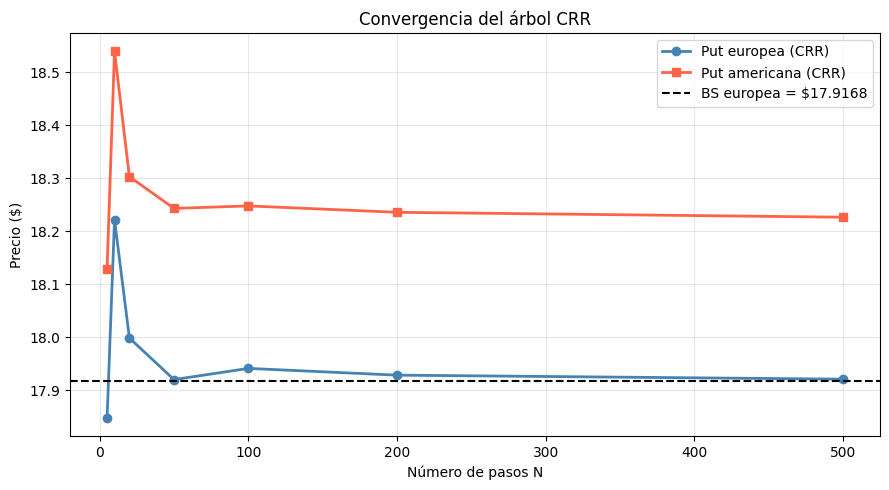

In [ ]:
# Precio vs. número de pasos
pasos   = [5, 10, 20, 50, 100, 200, 500]
precios_euro = [arbol_crr(S0, K, r, T, sigma, n, 'put', 'european') for n in pasos]
precios_amer = [arbol_crr(S0, K, r, T, sigma, n, 'put', 'american') for n in pasos]

# Precio BS como referencia
from scipy.stats import norm
d1 = (np.log(S0/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
d2 = d1 - sigma*np.sqrt(T)
bs_put = K*np.exp(-r*T)*norm.cdf(-d2) - S0*norm.cdf(-d1)

plt.figure(figsize=(9, 5))
plt.plot(pasos, precios_euro, marker='o', color='steelblue',
         linewidth=2, label='Put europea (CRR)')
plt.plot(pasos, precios_amer, marker='s', color='tomato',
         linewidth=2, label='Put americana (CRR)')
plt.axhline(bs_put, color='black', linestyle='--',
            label=f'BS europea = ${bs_put:.4f}')
plt.xlabel('Número de pasos N')
plt.ylabel('Precio ($)')
plt.title('Convergencia del árbol CRR')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

##  Prima por ejercicio anticipado en función del moneyness

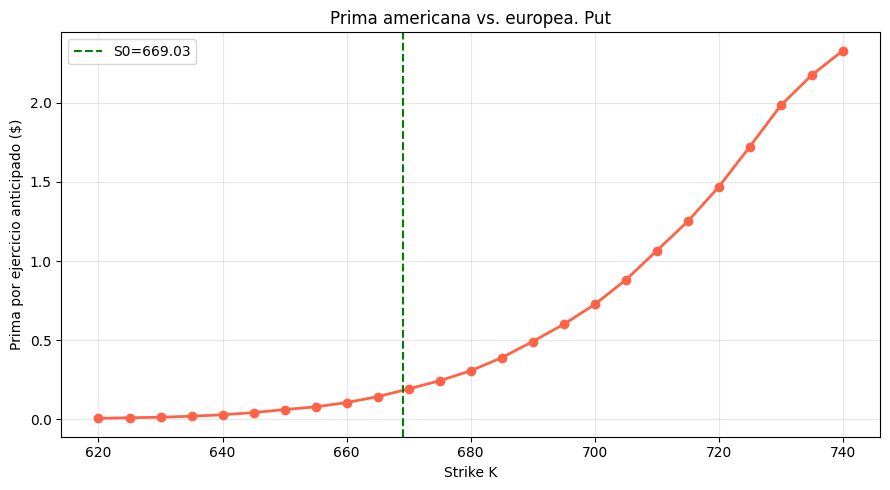

In [ ]:
K_range      = np.arange(620, 741, 5)
prima_antic  = []

for k in K_range:
    euro = arbol_crr(S0, k, r, T, sigma, 100, 'put', 'european')
    amer = arbol_crr(S0, k, r, T, sigma, 100, 'put', 'american')
    prima_antic.append(amer - euro)

plt.figure(figsize=(9, 5))
plt.plot(K_range, prima_antic, color='tomato', linewidth=2, marker='o')
plt.axvline(S0, color='green', linestyle='--', label=f'S0={S0}')
plt.xlabel('Strike K')
plt.ylabel('Prima por ejercicio anticipado ($)')
plt.title('Prima americana vs. europea. Put')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Comparación CRR vs. Black-Scholes

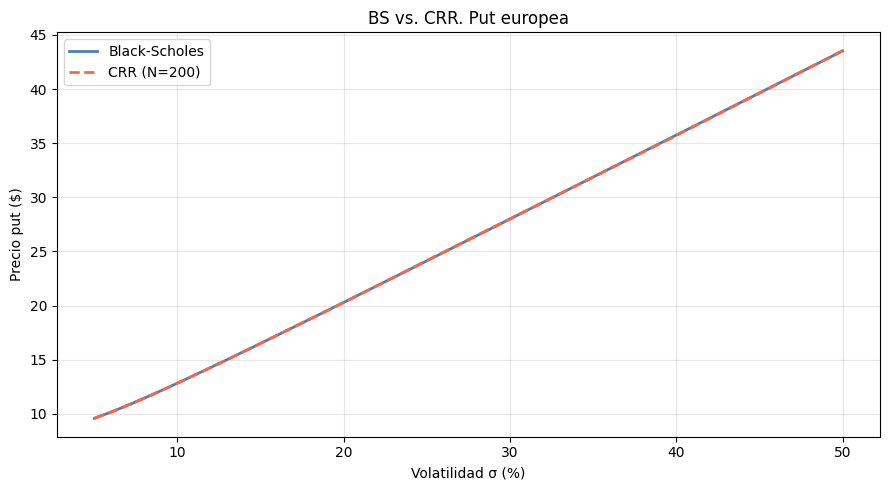

In [ ]:
sigma_range  = np.linspace(0.05, 0.50, 40)
bs_precios   = []
crr_precios  = []

for s in sigma_range:
    d1 = (np.log(S0/K) + (r + 0.5*s**2)*T) / (s*np.sqrt(T))
    d2 = d1 - s*np.sqrt(T)
    bs_precios.append(K*np.exp(-r*T)*norm.cdf(-d2) - S0*norm.cdf(-d1))
    crr_precios.append(arbol_crr(S0, K, r, T, s, 200, 'put', 'european'))

plt.figure(figsize=(9, 5))
plt.plot(sigma_range*100, bs_precios,  color='steelblue', linewidth=2,
         label='Black-Scholes')
plt.plot(sigma_range*100, crr_precios, color='tomato',    linewidth=2,
         linestyle='--', label='CRR (N=200)')
plt.xlabel('Volatilidad σ (%)')
plt.ylabel('Precio put ($)')
plt.title('BS vs. CRR. Put europea')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# **Preguntas de reflexión**

- **¿Por qué el ejercicio anticipado de una call sobre un activo sin dividendos nunca es óptimo? ¿Qué cambia si el activo paga dividendos?**

En el caso de una opción call sobre un activo que no paga dividendos, el ejercicio anticipado NO es óptimo porque implica perder el valor temporal de la opción y si el inversionista necesita liquidez, siempre es mejor vender la opción en el mercado que ejercerla; ya que la opción como tal tiene un valor superior a su valor intrínseco debido a la posibilidad de futuras alzas. Esto se confirma en el código, donde la call europea y la call americana tienen exactamente el mismo precio ($9.3925) y la prima por ejercicio anticipado es cero. En cambio, si el activo paga dividendos, puede ser conveniente ejercer la call justo antes del pago del dividendo para recibirlo, lo que podría hacer que la call americana valga más que la europea.

- **En la gráfica de convergencia, ¿por qué el precio oscila antes de converger? ¿Qué relación tiene eso con si N es par o impar?**

Las oscilaciones en el precio de la opción cuando se utiliza un número pequeño de pasos en el árbol binomial CRR se deben a la forma en que los nodos terminales se ubican respecto al strike. Si el número de pasos N es par o impar, los precios finales del activo pueden caer sistemáticamente por encima o por debajo del strike, lo que introduce un sesgo en el cálculo del pago de la opción. Cuando N es par = los nodos suelen distribuirse de manera más simétrica alrededor del strike, reduciendo el sesgo pero cuando N es impar = la asimetría puede generar precios alternativamente más altos o más bajos que el valor teórico de Black-Scholes. Esto explica las oscilaciones observadas en la gráfica para valores pequeños de N (como 5, 10 o 20) que se van amortiguando a medida que N aumenta y el árbol se aproxima a la distribución continua.

- **La prima por ejercicio anticipado es mayor para puts muy ITM. ¿Por qué intuitivamente tiene sentido ejercer anticipadamente una put muy ITM?**

Una opción put muy in-the-money (ITM) tiene un valor intrínseco elevado igual a la diferencia entre el strike y el precio del activo. Si se ejerce anticipadamente, el tenedor recibe ese efectivo de inmediato y puede invertirlo a la tasa libre de riesgo, generando intereses hasta la fecha de vencimiento original pero si espera hasta el vencimiento, pierde esa oportunidad de ganar intereses. Es decir, cuanto más profundo está ITM la put (mayor K en relación con S0), mayor es el incentivo para ejercer antes, la gráfica de prima por ejercicio anticipado muestra valores crecientes a medida que el strike K aumenta por encima del precio inicial S0 = 669.03.

- **Si aumentas T de 31 días a 1 año, ¿cómo esperas que cambie la diferencia entre la put americana y la europea? ¿Por qué?**

Si se aumenta el tiempo hasta el vencimiento T de 31 días a 1 año, la diferencia entre el precio de la put americana y la put europea tendería a aumentar. Un plazo más largo otorga más oportunidades para que el activo baje de precio, lo que incrementa el valor de la opción put; además, con un horizonte más extenso, el beneficio de ejercer anticipadamente (recibir efectivo y generar intereses) se potencia porque hay más tiempo para que esos intereses se acumulen. Por lo tanto, la prima por ejercicio anticipado (la ventaja de la versión americana sobre la europea) crece con T, ya que la flexibilidad de ejercer en cualquier momento se vuelve más valiosa cuanto mayor es el período hasta el vencimiento

- **El árbol CRR usa probabilidades neutrales al riesgo p, no probabilidades reales. ¿Qué significa eso y por qué es válido para el pricing?**

Las probabilidades neutrales al riesgo no representan las probabilidades reales de que el activo suba o baje en el mundo real, son probabilidades ajustadas que hacen que el rendimiento esperado del activo bajo esa medida sea igual a la tasa libre de riesgo r. En un mercado sin arbitraje, el precio de cualquier activo financiero puede calcularse como el valor esperado de sus flujos futuros descontados a la tasa libre de riesgo, siempre que se utilicen estas probabilidades neutrales al riesgo. En la actividad demuestra cómo se va descontando el valor esperado de la opción en cada paso con el factor, lo cual permite obtener precios consistentes con la ausencia de arbitraje y que convergen al modelo de Black-Scholes cuando N es grande.